In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../Loan_Data/train.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()
print(df.dtypes)

Shape: (614, 13)

First 5 rows:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


In [2]:
# Check missing values
print("Missing Values (Top 15):")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(15))

print("\nBasic Statistics:")
print(df.describe())

Missing Values (Top 15):
Credit_History      50
Self_Employed       32
LoanAmount          22
Dependents          15
Loan_Amount_Term    14
Gender              13
Married              3
dtype: int64

Basic Statistics:
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min       

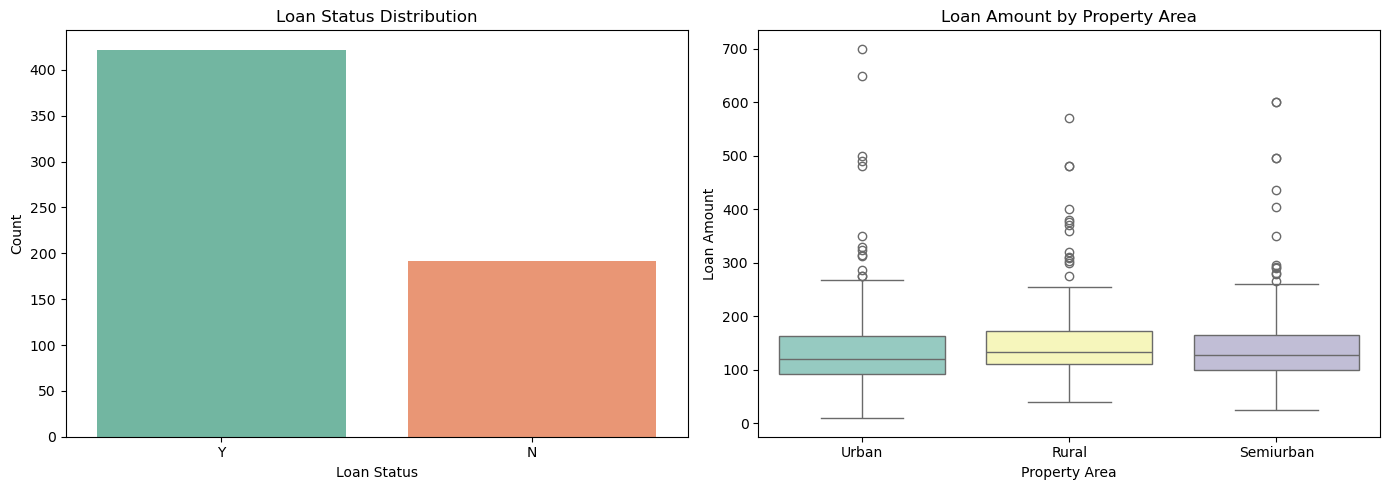

In [3]:
# Visualize Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Loan Status Distribution
sns.countplot(x='Loan_Status', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Loan Status Distribution')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Count')

# Chart 2 - Loan Amount by Property Area
sns.boxplot(x='Property_Area', y='LoanAmount', data=df, ax=axes[1], palette='Set3')
axes[1].set_title('Loan Amount by Property Area')
axes[1].set_xlabel('Property Area')
axes[1].set_ylabel('Loan Amount')

plt.tight_layout()
plt.show()

Top Features Correlated with Loan Status:
Loan_Status_Numeric    1.000000
Credit_History         0.561678
ApplicantIncome       -0.004710
Loan_Amount_Term      -0.021268
LoanAmount            -0.037318
CoapplicantIncome     -0.059187
Name: Loan_Status_Numeric, dtype: float64


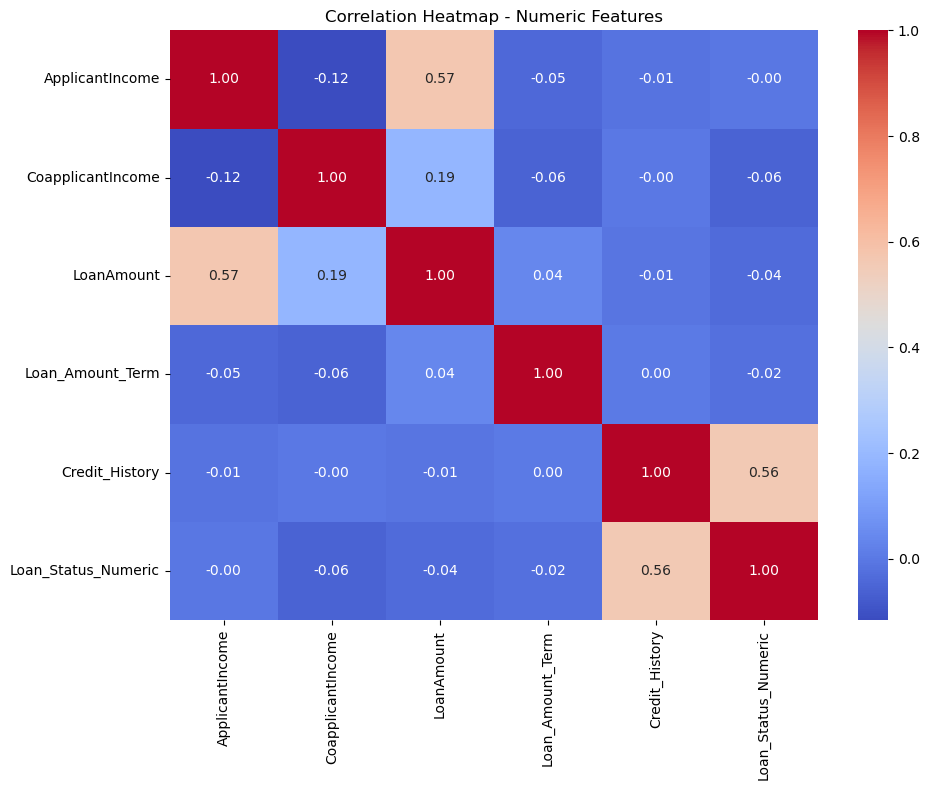

In [4]:
# Map target to numeric for correlation
df['Loan_Status_Numeric'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Top features correlated with Loan_Status_Numeric
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()['Loan_Status_Numeric'].sort_values(ascending=False)

print("Top Features Correlated with Loan Status:")
print(correlation)

# Heatmap of top features
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.show()

# Drop temporary column
df.drop('Loan_Status_Numeric', axis=1, inplace=True)

In [5]:
# Select top features (Feature Selection)
features = ['Credit_History', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

# Prepare data
X = df[features].copy()
y = df['Loan_Status'].copy()

# 1. Handle missing values properly (Impute with Median)
for col in features:
    X[col] = X[col].fillna(X[col].median())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

# Train Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_predictions)

# Train Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_predictions)

# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_predictions)

print("\nModel Performance:")
print(f"Logistic Regression - Accuracy: {lr_acc:.4f}")
print(f"Decision Tree       - Accuracy: {dt_acc:.4f}")
print(f"Random Forest       - Accuracy: {rf_acc:.4f}")


Training set size: (491, 5)
Testing set size: (123, 5)

Model Performance:
Logistic Regression - Accuracy: 0.7886
Decision Tree       - Accuracy: 0.7805
Random Forest       - Accuracy: 0.7642
